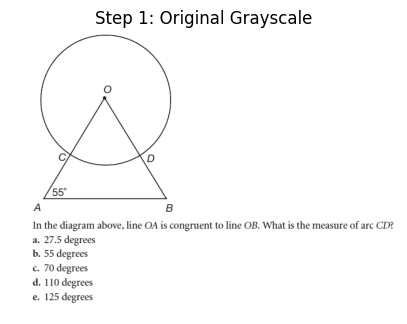

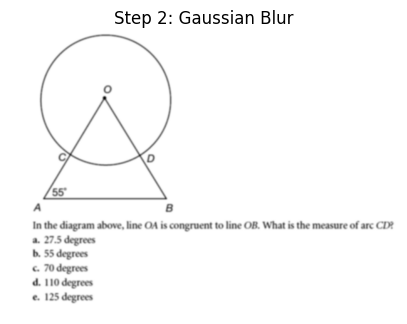

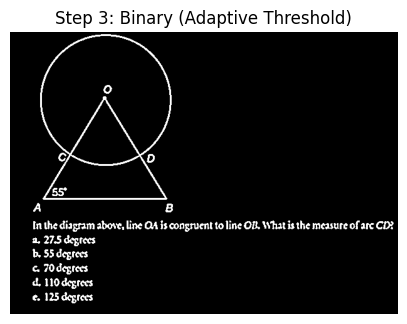

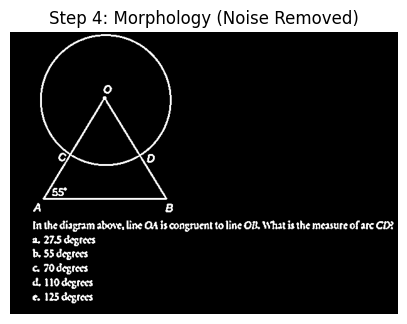

Final outline image saved as extracted_outline.png


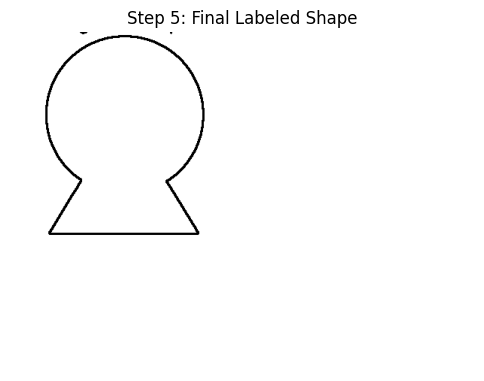

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Step 1: Original Grayscale Image
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", image)

    # Step 2: Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    plt.figure(figsize=(5, 5))
    plt.imshow(blurred, cmap='gray')
    plt.title("Step 2: Gaussian Blur")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_blurred.png", blurred)

    # Step 3: Apply adaptive thresholding to binarize image
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 3: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step3_binary.png", binary)

    # Step 4: Remove noise using morphological operations
    kernel = np.ones((1, 1), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(cleaned, cmap='gray')
    plt.title("Step 4: Morphology (Noise Removed)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step4_cleaned.png", cleaned)

    return cleaned

def find_and_label_shape(image_path, output_path="extracted_outline.png"):
    # Preprocess and get the cleaned image
    cleaned = preprocess_image(image_path)

    # Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("No contours found.")
        return

    # Load original image and create a blank white image for outlines
    original_image = cv2.imread(image_path)
    outline_image = np.ones_like(original_image) * 255

    # Identify the largest contour (assumed to be the main shape)
    largest_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(outline_image, [largest_contour], -1, (0, 0, 0), 2)

    # Approximate the contour for shape recognition
    epsilon = 0.02 * cv2.arcLength(largest_contour, True)
    approx = cv2.approxPolyDP(largest_contour, epsilon, True)

    # Identify shape based on number of sides
    num_sides = len(approx)
    shape_name = "Unknown"
    if num_sides == 3:
        shape_name = "Triangle"
    elif num_sides == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        shape_name = "Square" if 0.9 <= aspect_ratio <= 1.1 else "Rectangle"
    elif num_sides == 5:
        shape_name = "Pentagon"
    elif num_sides == 6:
        shape_name = "Hexagon"
    else:
        shape_name = "Circle" if cv2.isContourConvex(approx) else "Irregular Shape"

    # Label the shape
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.putText(outline_image, shape_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    # Save and display final result
    cv2.imwrite(output_path, outline_image)
    print(f"Final outline image saved as {output_path}")

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(outline_image, cv2.COLOR_BGR2RGB))
    plt.title("Step 5: Final Labeled Shape")
    plt.axis("off")
    plt.show()

# Example usage
image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\WorkingFIles\step1_grayscale.png"
find_and_label_shape(image_path)